# Assignment-9: K-Means Clustering


## Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
print('Libraries imported')

Libraries imported


###  Load Iris Dataset 

In [3]:
iris = load_iris(as_frame=True)
df = iris.frame.copy()
df = df.drop(columns=['target'])
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## Dataset Overview

In [4]:
print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
df.describe()

Shape: (150, 4)

Columns: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## Select Features for Clustering 

In [5]:
X = df[['sepal length (cm)', 'sepal width (cm)']]
X.head()

,sepal length (cm),sepal width (cm)
0,5.1,3.5
1,4.9,3.0
2,4.7,3.2
3,4.6,3.1
4,5.0,3.6


## Visualize Raw Data (Scatter Plot)

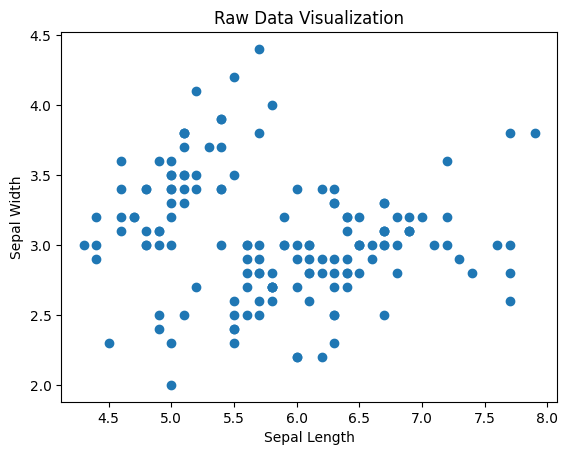

In [6]:
plt.scatter(X.iloc[:,0], X.iloc[:,1])
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('Raw Data Visualization')
plt.show()

## Apply K-Means Algorithm (K = 3)

In [7]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)
print('Model trained')

Model trained


F:\ana_1\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


## Assign Cluster Labels to Dataset

In [8]:
X_clustered = X.copy()
X_clustered['Cluster'] = kmeans.labels_
X_clustered.head()

,sepal length (cm),sepal width (cm),Cluster
0,5.1,3.5,2
1,4.9,3.0,2
2,4.7,3.2,2
3,4.6,3.1,2
4,5.0,3.6,2


## Elbow Method to Find Best K

F:\ana_1\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
F:\ana_1\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
F:\ana_1\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
F:\ana_1\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. Y

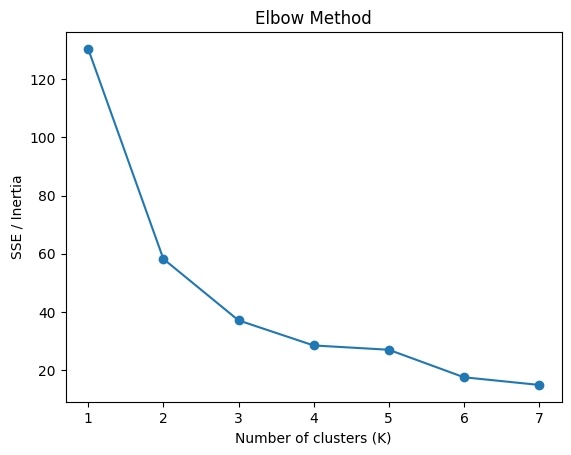

In [9]:
sse = []
K = range(1, 8)
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    sse.append(km.inertia_)

plt.plot(K, sse, marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('SSE / Inertia')
plt.title('Elbow Method')
plt.show()

## Visualize Final Clusters with Centroids

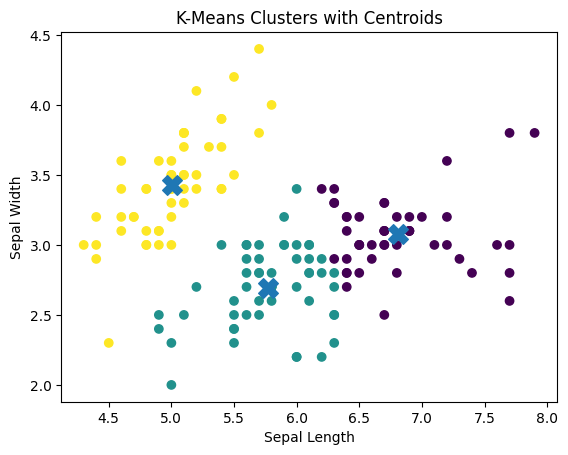

In [10]:
plt.scatter(X.iloc[:,0], X.iloc[:,1], c=kmeans.labels_)
centers = kmeans.cluster_centers_
plt.scatter(centers[:,0], centers[:,1], marker='X', s=200)
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('K-Means Clusters with Centroids')
plt.show()

## Conclusion 

### Conclusion

**Observations from this Experiment:**
In this experiment using the Iris dataset with 'sepal length (cm)' and 'sepal width (cm)' as features, we observed the following:
*   **Optimal K:** The Elbow Method suggested that `K=3` was an optimal number of clusters for this particular feature set, as the decrease in SSE (Sum of Squared Errors) started to level off around this point.
*   **Cluster Separation:** The K-Means algorithm effectively partitioned the data into three visually distinct clusters. One cluster predominantly consisted of data points with smaller sepal lengths and larger sepal widths, indicating a clear group. The other two clusters, while distinct, showed some degree of overlap, suggesting that while 'sepal length' and 'sepal width' are useful, they might not fully differentiate all natural groupings within the Iris species without additional features.
*   **Centroids:** The calculated centroids provided a representative 'center' for each cluster, helping to characterize the typical 'sepal length' and 'sepal width' values for the data points within that cluster.